In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# パウリ行列の定義
I = np.array([[1, 0], [0, 1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

def density_matrix_from_bloch(theta, phi):
    """ブロッホ球上の座標(theta, phi)から密度行列を生成"""
    # 状態ベクトル|psi> = cos(theta/2)|0> + e^(i*phi)sin(theta/2)|1>
    c = np.cos(theta / 2)
    s = np.sin(theta / 2) * np.exp(1j * phi)
    psi = np.array([c, s])
    return np.outer(psi, np.conj(psi))

def get_bloch_vector(rho):
    """密度行列からブロッホベクトル(x, y, z)を抽出"""
    x = np.real(np.trace(np.dot(rho, X)))
    y = np.real(np.trace(np.dot(rho, Y)))
    z = np.real(np.trace(np.dot(rho, Z)))
    return x, y, z

In [2]:
def apply_kraus(rho, kraus_ops):
    """クラウス演算子を用いてチャネルを適用"""
    new_rho = np.zeros_like(rho)
    for K in kraus_ops:
        new_rho += K @ rho @ K.conj().T
    return new_rho

def plot_deformed_bloch(kraus_func, param, title):
    """指定されたチャネルでブロッホ球を変形してプロット"""
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')

    # 球面メッシュの生成
    u = np.linspace(0, 2 * np.pi, 30) # phi
    v = np.linspace(0, np.pi, 15) # theta

    x_new = np.zeros((len(u), len(v)))
    y_new = np.zeros((len(u), len(v)))
    z_new = np.zeros((len(u), len(v)))

    kraus_ops = kraus_func(param)

    for i in range(len(u)):
        for j in range(len(v)):
            rho = density_matrix_from_bloch(v[j], u[i])
            rho_prime = apply_kraus(rho, kraus_ops)
            bx, by, bz = get_bloch_vector(rho_prime)
            x_new[i, j] = bx
            y_new[i, j] = by
            z_new[i, j] = bz

    # 元のブロッホ球の枠線を描画
    x_orig = np.outer(np.cos(u), np.sin(v))
    y_orig = np.outer(np.sin(u), np.sin(v))
    z_orig = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_wireframe(x_orig, y_orig, z_orig, color='gray', alpha=0.5, linewidth=0.3)

    # ノイズ適用後の状態をプロット
    ax.plot_surface(x_new, y_new, z_new, color='c', alpha=0.6, edgecolor='b', linewidth=0.3)
    ax.set_title(title)
    ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1]); ax.set_zlim([-1, 1])
    ax.set_box_aspect([1,1,1])
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    plt.show()

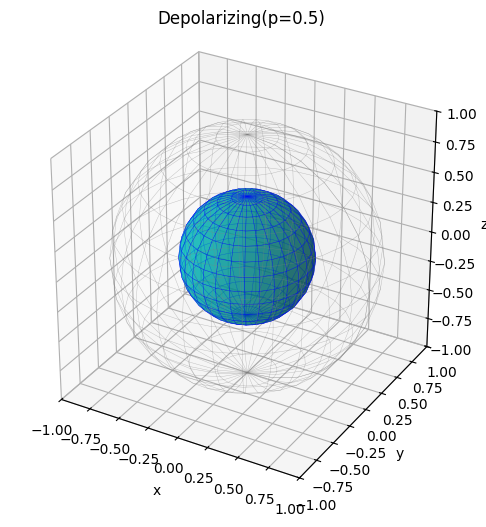

In [3]:
def get_depolarizing_kraus(p):
    p_prime = 3 * p / 4
    K0 = np.sqrt(1 - p_prime) * I
    K1 = np.sqrt(p_prime / 3) * X
    K2 = np.sqrt(p_prime / 3) * Y
    K3 = np.sqrt(p_prime / 3) * Z
    return [K0, K1, K2, K3]

plot_deformed_bloch(get_depolarizing_kraus, 0.5, "Depolarizing(p=0.5)")

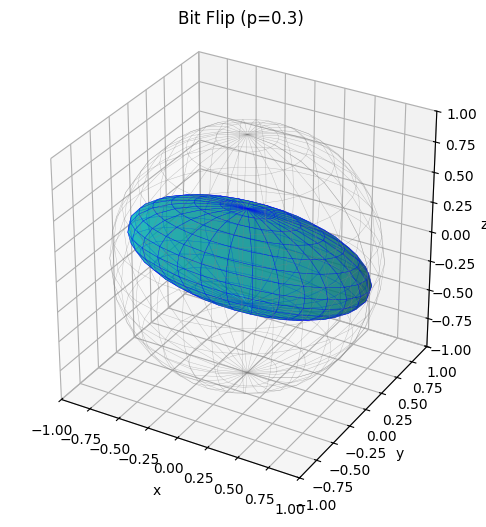

In [4]:
def get_bitflip_kraus(p):
    K0 = np.sqrt(1 - p) * I
    K1 = np.sqrt(p) * X
    return [K0, K1]

plot_deformed_bloch(get_bitflip_kraus, 0.3, "Bit Flip (p=0.3)")

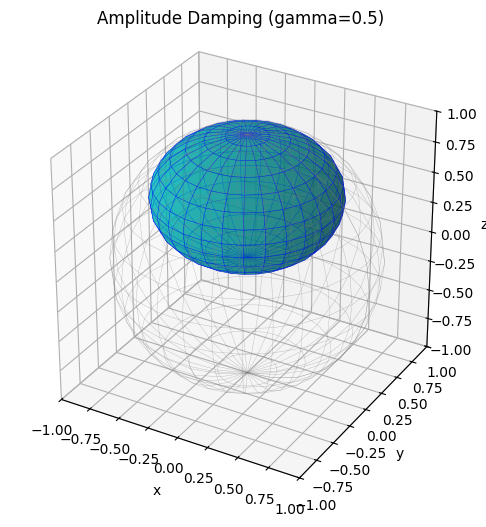

In [5]:
def get_amp_damping_kraus(gamma):
    K0 = np.array([[1, 0], [0, np.sqrt(1 - gamma)]], dtype=complex)
    K1 = np.array([[0, np.sqrt(gamma)], [0, 0]], dtype=complex)
    return [K0, K1]

plot_deformed_bloch(get_amp_damping_kraus, 0.5, "Amplitude Damping (gamma=0.5)")